<a href="https://colab.research.google.com/github/Dulandi-Dinethya/SE4050-Deep_Learning_Assignment/blob/IT23136274/results/models/03_ResNet50_IT23136274.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


ResNet50-Based Palmprint Recognition
Project: Deep Learning-Based Palmprint Recognition System for Contactless Biometric Identification and Authentication of Registered Users

Model: ResNet50

Student ID: IT23136274

## 1. Environment Setup and Imports

This section imports the required libraries for implementing the ResNet50-based palmprint recognition model.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dropout,
    Dense
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


## 2. ResNet50 Model Configuration

The ResNet50 model will use transfer learning with ImageNet pretrained weights. The input image size is set to 224 × 224 pixels with three RGB channels.

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

NUM_CLASSES = 600

INITIAL_LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5

print("Image size:", (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
print("Number of classes:", NUM_CLASSES)

Image size: (224, 224, 3)
Number of classes: 600


## 3. ResNet50 Transfer Learning Architecture

A ResNet50 model pretrained on ImageNet is used as the feature extractor. The original classification layer is removed and replaced with a custom classification head for palmprint identification.

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
)

print("ResNet50 base model loaded successfully.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 base model loaded successfully.


In [ ]:
base_model.trainable = False

print("Base model trainable:", base_model.trainable)

Base model trainable: False


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D(name="global_average_pooling")(x)

x = Dropout(
    DROPOUT_RATE,
    name="dropout"
)(x)

output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="palm_identity"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

print("ResNet50 palmprint model created successfully.")

ResNet50 palmprint model created successfully.


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,817,112 (94.67 MB)

 Trainable params: 1,229,400 (4.69 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 4. Training Callbacks

Training callbacks are configured to monitor validation performance, reduce the learning rate when improvement slows, stop training when validation performance no longer improves, and save the best-performing model.

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Save the best model during training
checkpoint_path = "best_resnet50_palmprint.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Training callbacks configured successfully.")

Training callbacks configured successfully.


## 5. Dataset Integration

The preprocessed palmprint dataset is loaded from Google Drive. The dataset contains two sessions that will be used according to the common experimental split defined for all models.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATASET_DIR = "/content/drive/MyDrive/SE_4050_Palm_Dataset"

print("Dataset folder exists:", os.path.exists(DATASET_DIR))

if os.path.exists(DATASET_DIR):
    print("\nAvailable files:")
    for item in os.listdir(DATASET_DIR):
        print("-", item)

Mounted at /content/drive
Dataset folder exists: True

Available files:
- session1.zip
- session2.zip


In [ ]:
import zipfile
import os

SESSION1_ZIP = os.path.join(DATASET_DIR, "session1.zip")
SESSION2_ZIP = os.path.join(DATASET_DIR, "session2.zip")

EXTRACT_DIR = "/content/palm_dataset"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(SESSION1_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

with zipfile.ZipFile(SESSION2_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extraction completed.")
print("Extracted contents:", os.listdir(EXTRACT_DIR))

Dataset extraction completed.
Extracted contents: ['session1', 'session2']


In [ ]:
SESSION1_DIR = os.path.join(EXTRACT_DIR, "session1")
SESSION2_DIR = os.path.join(EXTRACT_DIR, "session2")

session1_files = sorted(os.listdir(SESSION1_DIR))
session2_files = sorted(os.listdir(SESSION2_DIR))

print("Session 1 image count:", len(session1_files))
print("Session 2 image count:", len(session2_files))

print("\nFirst 10 files in Session 1:")
print(session1_files[:10])

print("\nFirst 10 files in Session 2:")
print(session2_files[:10])

Session 1 image count: 5994
Session 2 image count: 5994

First 10 files in Session 1:
['00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png', '00010.png']

First 10 files in Session 2:
['00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png', '00010.png']


In [ ]:
expected_files = {f"{i:05d}.png" for i in range(1, 6001)}

session1_set = set(session1_files)
session2_set = set(session2_files)

missing_session1 = sorted(expected_files - session1_set)
missing_session2 = sorted(expected_files - session2_set)

print("Missing files in Session 1:", len(missing_session1))
print(missing_session1)

print("\nMissing files in Session 2:", len(missing_session2))
print(missing_session2)

print("\nSame missing files in both sessions:",
      missing_session1 == missing_session2)

Missing files in Session 1: 6
['02795.png', '02798.png', '02897.png', '05444.png', '05452.png', '05457.png']

Missing files in Session 2: 6
['02432.png', '02655.png', '02656.png', '04506.png', '04507.png', '05215.png']

Same missing files in both sessions: False


In [ ]:
def get_palm_label(filename):
    """
    Convert palm image filename to identity label.

    00001-00010 -> class 0
    00011-00020 -> class 1
    ...
    05991-06000 -> class 599
    """
    image_number = int(os.path.splitext(filename)[0])
    return (image_number - 1) // 10


# Create Session 1 paths and labels
session1_paths = [
    os.path.join(SESSION1_DIR, filename)
    for filename in session1_files
]

session1_labels = [
    get_palm_label(filename)
    for filename in session1_files
]


# Create Session 2 paths and labels
session2_paths = [
    os.path.join(SESSION2_DIR, filename)
    for filename in session2_files
]

session2_labels = [
    get_palm_label(filename)
    for filename in session2_files
]


print("Session 1 samples:", len(session1_paths))
print("Session 2 samples:", len(session2_paths))

print("\nNumber of Session 1 classes:", len(set(session1_labels)))
print("Number of Session 2 classes:", len(set(session2_labels)))

print("\nLabel range Session 1:",
      min(session1_labels), "-", max(session1_labels))

print("Label range Session 2:",
      min(session2_labels), "-", max(session2_labels))

Session 1 samples: 5994
Session 2 samples: 5994

Number of Session 1 classes: 600
Number of Session 2 classes: 600

Label range Session 1: 0 - 599
Label range Session 2: 0 - 599


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert to NumPy arrays
session1_paths = np.array(session1_paths)
session1_labels = np.array(session1_labels)

session2_paths = np.array(session2_paths)
session2_labels = np.array(session2_labels)

# Split Session 1 into training and validation sets
train_paths, val_paths, train_labels, val_labels = train_test_split(
    session1_paths,
    session1_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=session1_labels
)

# Keep Session 2 completely separate for final testing
test_paths = session2_paths
test_labels = session2_labels

print("Training samples:", len(train_paths))
print("Validation samples:", len(val_paths))
print("Testing samples:", len(test_paths))

print("\nTraining classes:", len(np.unique(train_labels)))
print("Validation classes:", len(np.unique(val_labels)))
print("Testing classes:", len(np.unique(test_labels)))

Training samples: 4795
Validation samples: 1199
Testing samples: 5994

Training classes: 600
Validation classes: 600
Testing classes: 600


### 5.1 TensorFlow Data Pipeline

The image paths and labels are converted into TensorFlow datasets. Each palmprint image is decoded, converted to RGB, resized to 224 × 224 pixels, and preprocessed using the ResNet50 preprocessing function. The datasets are then batched and prefetched for efficient model training.

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label):
    # Read image
    image = tf.io.read_file(image_path)

    # Decode PNG as RGB
    image = tf.image.decode_png(image, channels=3)

    # Resize for ResNet50
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Apply ResNet50-specific preprocessing
    image = preprocess_input(image)

    return image, label


def create_dataset(paths, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = create_dataset(
    train_paths,
    train_labels,
    training=True
)

val_ds = create_dataset(
    val_paths,
    val_labels
)

test_ds = create_dataset(
    test_paths,
    test_labels
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Label range in batch:",
          int(tf.reduce_min(labels)),
          "-",
          int(tf.reduce_max(labels)))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Label range in batch: 3 - 538


## 6. Initial Training

The ResNet50 convolutional base is kept frozen during the initial training stage. Only the newly added classification layers are trained on the palmprint dataset. Validation performance is monitored during training using the configured callbacks.

In [ ]:
INITIAL_EPOCHS = 20

history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.0220 - loss: 7.1757
Epoch 1: val_loss improved from None to 3.29030, saving model to best_resnet50_palmprint.keras

Epoch 1: finished saving model to best_resnet50_palmprint.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 209ms/step - accuracy: 0.0678 - loss: 6.2318 - val_accuracy: 0.5638 - val_loss: 3.2903 - learning_rate: 0.0010
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4730 - loss: 2.8712
Epoch 2: val_loss improved from 3.29030 to 1.81034, saving model to best_resnet50_palmprint.keras

Epoch 2: finished saving model to best_resnet50_palmprint.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 121ms/step - accuracy: 0.5404 - loss: 2.5535 - val_accuracy: 0.7756 - val_loss: 1.8103 - learning_rate: 0.0010
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7682 - loss: 1.4436
Epoch 3: val_loss improved from 1.81034 to 1.25812, saving model to best_resnet50_palmprint.keras

Epoch 3: finished saving mod

In [ ]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 7. Fine-Tuning

### 7.1 Initial Training Performance

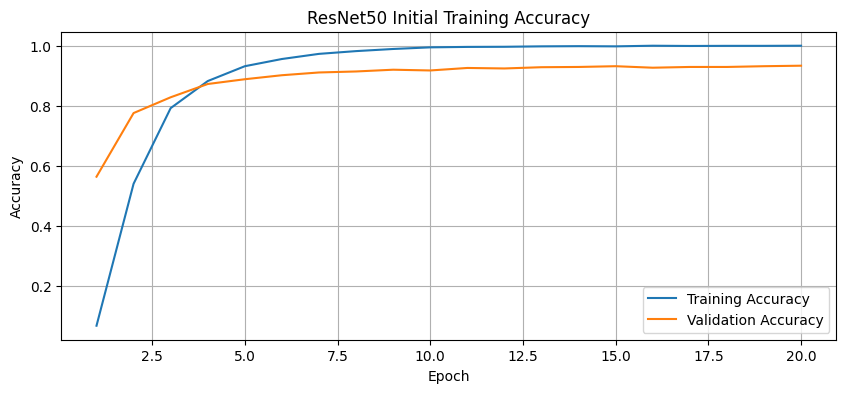

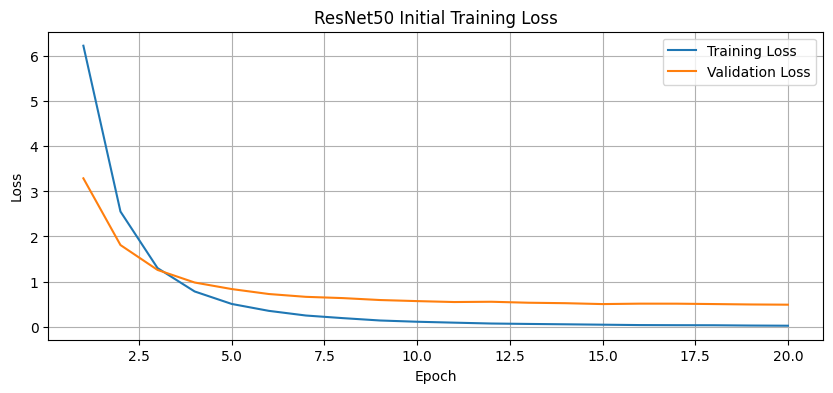

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_initial.history["accuracy"]) + 1)

plt.figure(figsize=(10, 4))

plt.plot(
    epochs,
    history_initial.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_initial.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Initial Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))

plt.plot(
    epochs,
    history_initial.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history_initial.history["val_loss"],
    label="Validation Loss"
)

plt.title("ResNet50 Initial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 7.2 Fine-Tuning the ResNet50 Base Model

To improve task-specific feature learning, the final layers of the pretrained ResNet50 base model are unfrozen while the earlier layers remain frozen. A lower learning rate is used during fine-tuning to avoid large changes to the pretrained ImageNet weights.

In [ ]:
# Enable the base model for fine-tuning
base_model.trainable = True

# Keep most pretrained layers frozen
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stable fine-tuning
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base model layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)

trainable_layers = sum(
    1 for layer in base_model.layers if layer.trainable
)

print("Trainable base model layers:", trainable_layers)

Total base model layers: 175
Fine-tuning from layer: 145
Trainable base model layers: 21


### Recompile with a low learning rate

In [ ]:
from tensorflow.keras.optimizers import Adam

FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")
print("Fine-tuning learning rate:", FINE_TUNE_LR)

Model recompiled for fine-tuning.
Fine-tuning learning rate: 1e-05


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

fine_tune_checkpoint = "best_resnet50_finetuned.keras"

fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=fine_tune_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Fine-tuning callbacks configured successfully.")

Fine-tuning callbacks configured successfully.


In [ ]:
FINE_TUNE_EPOCHS = 10

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9994 - loss: 0.0087
Epoch 1: val_loss improved from None to 0.56398, saving model to best_resnet50_finetuned.keras

Epoch 1: finished saving model to best_resnet50_finetuned.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 241ms/step - accuracy: 0.9996 - loss: 0.0069 - val_accuracy: 0.9283 - val_loss: 0.5640 - learning_rate: 1.0000e-05
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9988 - loss: 0.0057
Epoch 2: val_loss did not improve from 0.56398
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 146ms/step - accuracy: 0.9987 - loss: 0.0068 - val_accuracy: 0.9258 - val_loss: 0.5667 - learning_rate: 1.0000e-05
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9992 - loss: 0.0046
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 3: val_loss did not improve from 0.56398
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.9996 - loss: 0.0038 - val_accuracy: 0.9299 - val_l

## 8. Final Testing

Fine-tuning did not improve validation performance compared with the initial transfer-learning model. Therefore, the best model obtained during initial training is selected for final evaluation on the unseen Session 2 test set.

In [33]:
from tensorflow.keras.models import load_model

best_model = load_model("best_resnet50_palmprint.keras")

print("Best initial ResNet50 model loaded successfully.")

Best initial ResNet50 model loaded successfully.


Final Test Evaluation

In [34]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFinal Test Results")
print("------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - accuracy: 0.5244 - loss: 3.5761

Final Test Results
------------------
Test Loss     : 3.5761
Test Accuracy : 0.5244
Test Accuracy : 52.44%


## 9. Evaluation Metrics

The final ResNet50 model is evaluated on the unseen Session 2 test set using accuracy, precision, recall, F1-score, and a confusion matrix.

In [35]:
import numpy as np

# Generate predictions on the final test set
y_prob = best_model.predict(test_ds, verbose=1)

# Predicted class for each image
y_pred = np.argmax(y_prob, axis=1)

# True labels
y_true = test_labels

print("Number of predictions:", len(y_pred))
print("Number of true labels:", len(y_true))

print("Predicted label range:", y_pred.min(), "-", y_pred.max())
print("True label range:", y_true.min(), "-", y_true.max())

188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 114ms/step
Number of predictions: 5994
Number of true labels: 5994
Predicted label range: 0 - 599
True label range: 0 - 599


Precision, Recall, F1

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)

macro_precision = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

print("Final ResNet50 Classification Metrics")
print("-------------------------------------")
print(f"Accuracy           : {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nMacro Average")
print(f"Precision          : {macro_precision:.4f}")
print(f"Recall             : {macro_recall:.4f}")
print(f"F1-Score           : {macro_f1:.4f}")

print("\nWeighted Average")
print(f"Precision          : {weighted_precision:.4f}")
print(f"Recall             : {weighted_recall:.4f}")
print(f"F1-Score           : {weighted_f1:.4f}")

Final ResNet50 Classification Metrics
-------------------------------------
Accuracy           : 0.5244 (52.44%)

Macro Average
Precision          : 0.5210
Recall             : 0.5246
F1-Score           : 0.4905

Weighted Average
Precision          : 0.5207
Recall             : 0.5244
F1-Score           : 0.4902


Confusion Matrix

Confusion matrix shape: (600, 600)


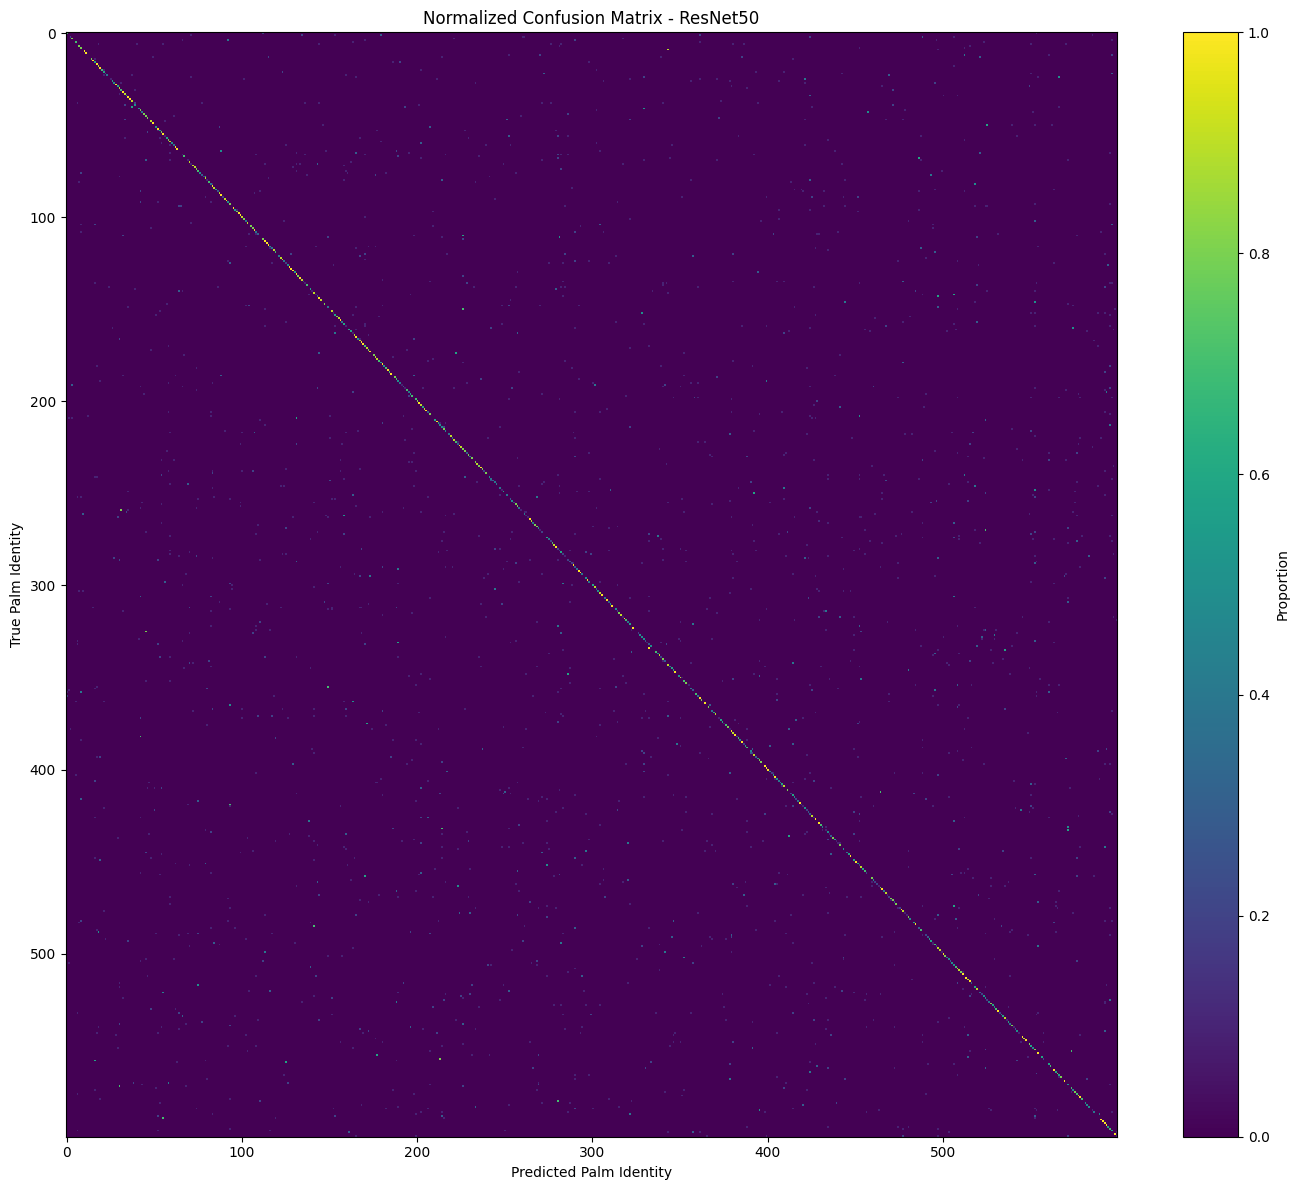

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Normalized confusion matrix
cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES),
    normalize="true"
)

print("Confusion matrix shape:", cm_normalized.shape)

plt.figure(figsize=(14, 12))

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    aspect="auto"
)

plt.title("Normalized Confusion Matrix - ResNet50")
plt.xlabel("Predicted Palm Identity")
plt.ylabel("True Palm Identity")

plt.colorbar(label="Proportion")

plt.tight_layout()
plt.show()

Final ResNet50 results summary

In [38]:
print("=" * 60)
print("FINAL RESNET50 RESULT SUMMARY")
print("=" * 60)

print(f"{'Model':<35}: ResNet50")
print(f"{'Number of Classes':<35}: {NUM_CLASSES}")
print(f"{'Input Size':<35}: {IMG_HEIGHT} x {IMG_WIDTH} x 3")

print("-" * 60)
print("DATASET")
print("-" * 60)

print(f"{'Training Samples':<35}: {len(train_paths)}")
print(f"{'Validation Samples':<35}: {len(val_paths)}")
print(f"{'Test Samples':<35}: {len(test_paths)}")

print("-" * 60)
print("INITIAL TRAINING")
print("-" * 60)

print(f"{'Final Training Accuracy':<35}: "
      f"{history_initial.history['accuracy'][-1] * 100:.2f}%")

best_val_acc = max(history_initial.history["val_accuracy"])
best_val_loss = min(history_initial.history["val_loss"])

print(f"{'Best Validation Accuracy':<35}: {best_val_acc * 100:.2f}%")
print(f"{'Best Validation Loss':<35}: {best_val_loss:.4f}")

print("-" * 60)
print("FINE-TUNING")
print("-" * 60)

best_ft_val_acc = max(history_fine.history["val_accuracy"])
best_ft_val_loss = min(history_fine.history["val_loss"])

print(f"{'Best Fine-Tuned Val Accuracy':<35}: "
      f"{best_ft_val_acc * 100:.2f}%")
print(f"{'Best Fine-Tuned Val Loss':<35}: {best_ft_val_loss:.4f}")

print("-" * 60)
print("FINAL TEST RESULTS")
print("-" * 60)

print(f"{'Test Accuracy':<35}: {test_accuracy * 100:.2f}%")
print(f"{'Test Loss':<35}: {test_loss:.4f}")

print("-" * 60)
print("CLASSIFICATION METRICS")
print("-" * 60)

print(f"{'Macro Precision':<35}: {macro_precision * 100:.2f}%")
print(f"{'Macro Recall':<35}: {macro_recall * 100:.2f}%")
print(f"{'Macro F1-Score':<35}: {macro_f1 * 100:.2f}%")

print(f"{'Weighted Precision':<35}: {weighted_precision * 100:.2f}%")
print(f"{'Weighted Recall':<35}: {weighted_recall * 100:.2f}%")
print(f"{'Weighted F1-Score':<35}: {weighted_f1 * 100:.2f}%")

print("=" * 60)

FINAL RESNET50 RESULT SUMMARY
Model                              : ResNet50
Number of Classes                  : 600
Input Size                         : 224 x 224 x 3
------------------------------------------------------------
DATASET
------------------------------------------------------------
Training Samples                   : 4795
Validation Samples                 : 1199
Test Samples                       : 5994
------------------------------------------------------------
INITIAL TRAINING
------------------------------------------------------------
Final Training Accuracy            : 99.98%
Best Validation Accuracy           : 93.33%
Best Validation Loss               : 0.4871
------------------------------------------------------------
FINE-TUNING
------------------------------------------------------------
Best Fine-Tuned Val Accuracy       : 92.99%
Best Fine-Tuned Val Loss           : 0.5640
------------------------------------------------------------
FINAL TEST RESULTS
---

## 10. Results Analysis

The ResNet50 transfer-learning model achieved very high performance on the training set, reaching approximately 99.98% training accuracy. On the validation set created from Session 1, the best model achieved 93.33% accuracy with a validation loss of 0.4871.

Fine-tuning the final layers of ResNet50 did not improve validation performance. The best fine-tuning epoch achieved approximately 92.83% validation accuracy with a validation loss of 0.5640. Therefore, the model obtained from the initial frozen-base training stage was selected for final testing.

On the unseen Session 2 test set, the selected model achieved 52.44% accuracy with a test loss of 3.5761. The macro precision, recall, and F1-score were 0.5210, 0.5246, and 0.4905 respectively, while the weighted precision, recall, and F1-score were 0.5207, 0.5244, and 0.4902.

The substantial difference between the Session 1 validation accuracy and Session 2 test accuracy indicates limited cross-session generalization. Although the model learned highly discriminative features from the training data, its performance decreased when evaluated on palmprint images captured in a separate session. This suggests that the model may have learned session-specific visual characteristics in addition to identity-related palmprint features.

The normalized confusion matrix shows a visible diagonal pattern, indicating correct predictions across many palm identities, while the off-diagonal values represent identities that were confused with other classes. Overall, ResNet50 demonstrated strong learning capability on the training and validation data but showed a significant generalization limitation when evaluated under the cross-session test condition.